# Практическое задание №5

In [206]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

Используйте данные из файла **advertising.csv** с информацией о клиентах интернет-магазина.

В нём содержаться следующие переменные:

| Название переменной | Описание переменной
|:-------------------:|:------------------:|
| Daily Time Spent on Site | consumer time on site in minutes |
| Age | cutomer age in years |
| Area Income | Avg. Income of geographical area of consumer |
| Daily Internet Usage | Avg. minutes a day consumer is on the internet |
| Ad Topic Line | Headline of the advertisement |
| City | City of consumer |
| Male | Whether or not consumer was male |
| Country |	Country of consumer |
| Timestamp | Time at which consumer clicked on Ad or closed window |
| Clicked on Ad | 0 or 1 indicated clicking on Ad |


Задача - создать модель, которая будет предсказывать, нажмет ли интернет-пользователь на рекламу, на основе характеристик этого пользователя.

Выполните, пожалуйста, следующие задания.

In [207]:
df = pd.read_csv('advertising.csv')
df.head(25)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0
5,59.99,23,59761.56,226.74,Sharable client-driven software,Jamieberg,1,Norway,2016-05-19 14:30:17,0
6,88.91,33,53852.85,208.36,Enhanced dedicated support,Brandonstad,0,Myanmar,2016-01-28 20:59:32,0
7,66.00,48,24593.33,131.76,Reactive local challenge,Port Jefferybury,1,Australia,2016-03-07 01:40:15,1
8,74.53,30,68862.00,221.51,Configurable coherent function,West Colin,1,Grenada,2016-04-18 09:33:42,0
9,69.88,20,55642.32,183.82,Mandatory homogeneous architecture,Ramirezton,1,Ghana,2016-07-11 01:42:51,0


1. Сформулируйте гипотезы, которые будут проверены в ходе исследования.

**Гипотезы:**
- Чем больше времени человек провел на сайте, чем выше вероятность того, что он откликнится на рекламу
- Чем больше средний доход по региону, тем выше шансы, что человек нажмет на рекламу
- Чем больше возраст человека, тем выше вероятность, что он откликниться на рекламу
- Вероятность откликнуться на рекламу больше у покупателей, проживающих в развытых или развивающихся странах, Европе, Северной Америки, чем у покупателей из отсталых стран, например, стран Африки
- Женщины чаще откликаются на рекламу, чем мужчины

2. Постройте модель бинарной логистической регрессии. Зависимая переменная – Clicked on Ad. В качестве предикторов выберите не менее 3 метрических переменных и не менее 2 категориальных переменных. Напишите уравнение регрессии (линейная часть). Охарактеризуйте регрессионную модель. Оцените статическую значимость и предсказательную силу модели. Постройте ROC-кривую и прокомментируйте ее. Рассчитайте площадь под ROC-кривой.

Рассмотрим 5 переменных

Метрические:
- Daily Time Spent on Site
- Area Income
- Age

Котегориальные:
- Male
- Country


In [208]:
df['Country'].value_counts()

,count
Country,
Czech Republic,9
France,9
Senegal,8
Peru,8
Greece,8
...,...
Kiribati,1
Marshall Islands,1
Bermuda,1


У нас слишком много уникальных значений стран, поэтому распределим страны по континентам. При распределении стран по континентам использовала ИИ для изучения библиотеки GeonamesCache.

In [209]:
!pip install geonamescache
from geonamescache import GeonamesCache

In [210]:
# Инициализация
gc = GeonamesCache()

In [211]:
# Создаем пустой словарь для сопоставления стран и континентов
continent_mapping = {}

# Проходим по всем странам в базе GeonamesCache
# gc.get_countries() возвращает словарь, где:
#   ключ - двухбуквенный код страны (например, 'US' для США)
#   значение - словарь с информацией о стране
for country_code, country_info in gc.get_countries().items():
    # Извлекаем полное название страны из информации о стране
    country_name = country_info['name']
    # Извлекаем код континента из информации о стране
    continent = country_info['continentcode']

    # Добавляем запись в словарь: название страны -> код континента
    continent_mapping[country_name] = continent

# Создание столбца с континентами
df['Continent'] = df['Country'].map(continent_mapping)

df.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Continent
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,AF
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,OC
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,EU
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,EU
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,EU


In [212]:
# Расшифровка символов:
# EU - Европ
# AS - Азия
# NA - Северная Америка
# SA - Южная Америка
# AF - Африка
# OC - Океания (Австралия и острова Тихого океана)
# AN - Антарктида
df['Continent'].value_counts() # Референтная группа EU

,count
Continent,
AF,199
EU,193
AS,182
NA,152
OC,110
SA,58
AN,10


In [213]:
# Создаем дамми-переменные в датафрейм
Continent_dummies=pd.get_dummies(df.Continent, prefix='Continent', prefix_sep='_', dtype=int)
Continent_dummies.head()

,Continent_AF,Continent_AN,Continent_AS,Continent_EU,Continent_NA,Continent_OC,Continent_SA
0,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0
2,0,0,0,1,0,0,0
3,0,0,0,1,0,0,0
4,0,0,0,1,0,0,0


In [214]:
# Добавляем дамми-переменные в датафрейм
df = pd.concat([df, Continent_dummies], axis=1)
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Continent,Continent_AF,Continent_AN,Continent_AS,Continent_EU,Continent_NA,Continent_OC,Continent_SA
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,AF,1,0,0,0,0,0,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,OC,0,0,0,0,0,1,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,EU,0,0,0,1,0,0,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,EU,0,0,0,1,0,0,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,EU,0,0,0,1,0,0,0


In [215]:
df_model1 = df.dropna(subset=['Daily Time Spent on Site', 'Area Income', 'Age', 'Male',
                              'Continent_AF', 'Continent_AN',	'Continent_AS',	'Continent_NA',
                              'Continent_OC', 'Continent_SA', 'Clicked on Ad'])
df_model1.shape

(1000, 18)

In [216]:
x_mult = df_model1[['Daily Time Spent on Site', 'Area Income', 'Age', 'Male',
                    'Continent_AF', 'Continent_AN',	'Continent_AS',	'Continent_NA',
                    'Continent_OC', 'Continent_SA']]
y = df_model1['Clicked on Ad']
x_mult_constant = sm.add_constant(x_mult)

In [217]:
model1 = sm.Logit(y, x_mult_constant).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.188455
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          Clicked on Ad   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      989
Method:                           MLE   Df Model:                           10
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.7281
Time:                        16:25:16   Log-Likelihood:                -188.46
converged:                       True   LL-Null:                       -693.15
Covariance Type:            nonrobust   LLR p-value:                1.780e-210
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       16.3648      1.595     10.261      0.000      13.239

In [218]:
coefs = pd.DataFrame()
coefs['Coefs'] = model1.params[1:]
coefs['Features'] = model1.params.index[1:]
coefs.set_index('Features', inplace=True)
print('Intercept = ', model1.params[0])
coefs

Intercept =  16.364836353088354


,Coefs
Features,
Daily Time Spent on Site,-0.217124
Area Income,-0.000121
Age,0.166029
Male,-0.720799
Continent_AF,0.046705
Continent_AN,-1.746216
Continent_AS,0.294900
Continent_NA,0.140147
Continent_OC,-0.195989


In [219]:
coefs['OddsRatio'] = np.exp(coefs.Coefs)
coefs

,Coefs,OddsRatio
Features,,
Daily Time Spent on Site,-0.217124,0.804830
Area Income,-0.000121,0.999879
Age,0.166029,1.180607
Male,-0.720799,0.486364
Continent_AF,0.046705,1.047813
Continent_AN,-1.746216,0.174433
Continent_AS,0.294900,1.342993
Continent_NA,0.140147,1.150443
Continent_OC,-0.195989,0.822021


Уравнение регрессии:

In [220]:
l = []
for (param, index) in zip(model1.params[1:], model1.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('logit(p) = {:2f} + {}'.format(model1.params[0], ' + '.join(l)))

logit(p) = 16.364836 + -0.22*Daily Time Spent on Site + -0.00*Area Income + 0.17*Age + -0.72*Male + 0.05*Continent_AF + -1.75*Continent_AN + 0.29*Continent_AS + 0.14*Continent_NA + -0.20*Continent_OC + -1.37*Continent_SA


Характеристика регрессионной модели:

Положительное влияние:
1. Возраст
2. Азия относительно Европы
3. Северная Амнрика относительно Европы

Отрицательное влияние:
1. Время на сайте
2. Мужской пол
3. Высокий доход района
4. Южная Америка и Антаркида относительно Европы, но в данных по Антаркиде очень мало

Без значимого влияния:
- Остальные континенты (кроме Юж. Америки и Антаркиды) не отличаются от Европы

In [221]:
print('R^2 = {:f}'.format(model1.prsquared))
print('Model significance = {:f}'.format(model1.llr_pvalue))

R^2 = 0.728117
Model significance = 0.000000


Модель статистически значима и обладает высокой предсказательной силой

In [223]:
fpr, tpr, _ = roc_curve(df_model1['Clicked on Ad'], model1.predict())
roc_auc = auc(fpr, tpr)

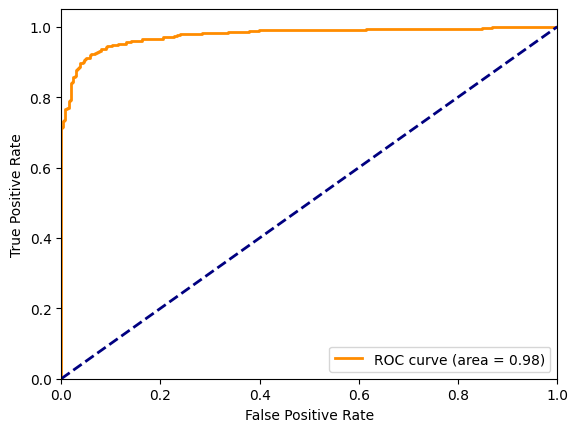

In [224]:
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

ROC-кривая стремится к левому верхнему углу, что свидетельствует о хорошей способности модели разделять пользователей, которые кликнут на рекламу

Площадь под кривой = 0.98

3. Оцените статистическую значимость регрессионных коэффициентов. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной на основе значений регрессионных коэффициентов.

In [225]:
def yes_no(p_value, level = 0.05):
    if abs(p_value) < level:
        return 'significant'
    else:
        return 'non-significant'

In [226]:
pvals = pd.DataFrame()
pvals['p_values'] = model1.pvalues[1:]
pvals['5% level']= pvals['p_values'].apply(yes_no)
pvals['p_values'] = pvals['p_values'].map('{:.3f}'.format)
pvals['Features'] = model1.params.index[1:]
pvals.set_index('Features',inplace=True)
pvals

,p_values,5% level
Features,,
Daily Time Spent on Site,0.000,significant
Area Income,0.000,significant
Age,0.000,significant
Male,0.011,significant
Continent_AF,0.904,non-significant
Continent_AN,0.349,non-significant
Continent_AS,0.477,non-significant
Continent_NA,0.734,non-significant
Continent_OC,0.691,non-significant


In [227]:
pvals['10% level'] = model1.pvalues[1:].apply(lambda x: yes_no(x, level=0.1))
pvals

,p_values,5% level,10% level
Features,,,
Daily Time Spent on Site,0.000,significant,significant
Area Income,0.000,significant,significant
Age,0.000,significant,significant
Male,0.011,significant,significant
Continent_AF,0.904,non-significant,non-significant
Continent_AN,0.349,non-significant,non-significant
Continent_AS,0.477,non-significant,non-significant
Continent_NA,0.734,non-significant,non-significant
Continent_OC,0.691,non-significant,non-significant


In [228]:
f'Статистически значимые предикторы: {model1.pvalues[model1.pvalues < 0.05].index.values}'

"Статистически значимые предикторы: ['const' 'Daily Time Spent on Site' 'Area Income' 'Age' 'Male'\n 'Continent_SA']"

In [229]:
f'Статистически не значимые предикторы: {model1.pvalues[model1.pvalues > 0.05].index.values}'

"Статистически не значимые предикторы: ['Continent_AF' 'Continent_AN' 'Continent_AS' 'Continent_NA'\n 'Continent_OC']"

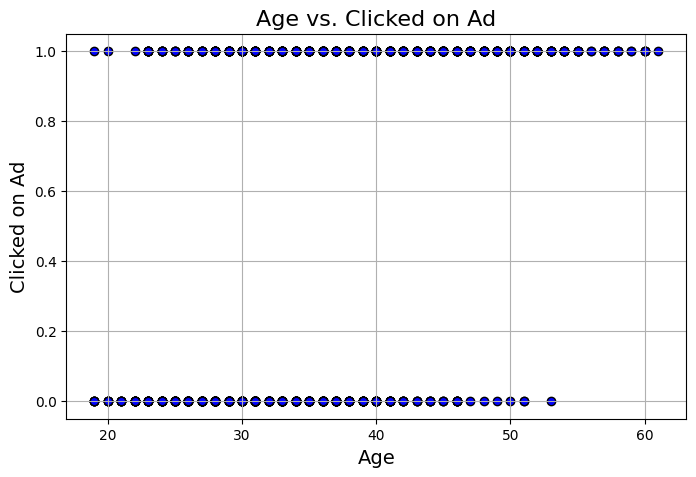

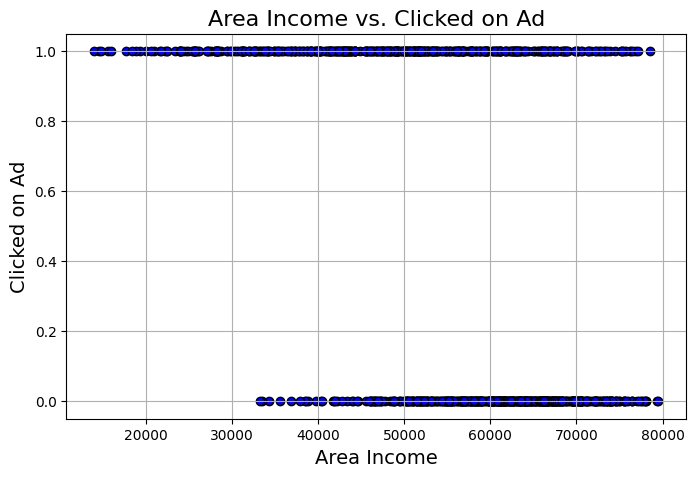

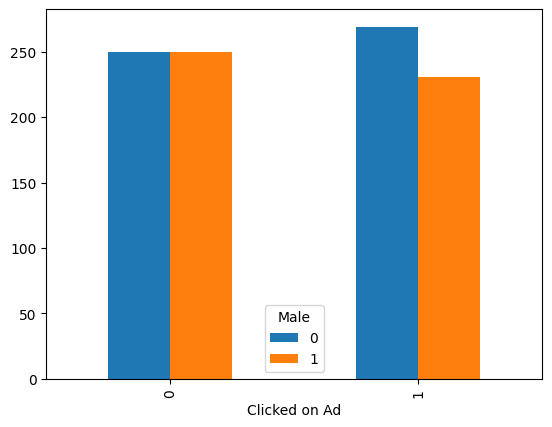

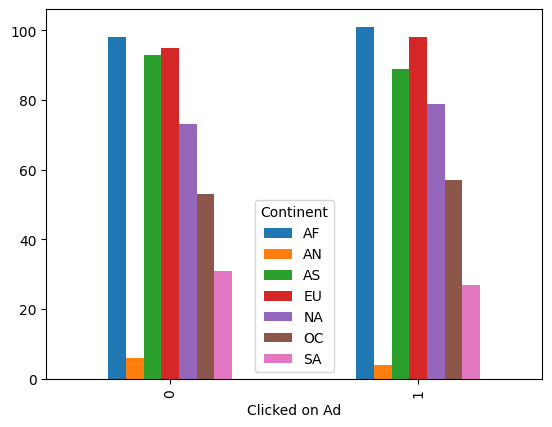

In [230]:
for c in df.columns[1:]:
    if c == 'Daily Time Spent on Site' or c == 'Area Income' or c=='Age':
        plt.figure(figsize=(8,5))
        plt.title('{} vs. Clicked on Ad'.format(c), fontsize=16)
        plt.scatter(x=df[c], y=df['Clicked on Ad'], color='blue',edgecolor='k')
        plt.grid(True)
        plt.xlabel(c, fontsize=14)
        plt.ylabel('Clicked on Ad', fontsize=14)
        plt.show()
    elif c == 'Male' or c == 'Continent':
        ct = pd.crosstab(df['Clicked on Ad'], df[c])
        ct.plot.bar()

Интерпретация коэффицентов:
- Чем больше времени на сайте, тем МЕНЬШЕ вероятность клика: каждая минута уменьшает шансы примерно на 19.5%
- Чем ВЫШЕ доход района, тем ниже вероятность отклика на рекламу: разница в $1000 дохода снижает шансы на 11.41%
- Чем старше пользователь, тем БОЛЬШЕ вероятность клика: каждый год возраста увеличивает шансы на 18%
- Мужчины на 51% РЕЖЕ откликаются на рекламу
- В Африке кликают на 5% ЧАЩЕ, чем в Европе
- В Антарктиде кликают на 83% РЕЖЕ, чем в Европе
- В Азии кликают на 34% ЧАЩЕ, чем в Европе
- В Южной Америки кликают на 75% РЕЖЕ, чем в Европе
- В Северной Америке кликают на 15% ЧАЩЕ, чем в Европе
- В Океании кликают на 18% РЕЖЕ, чем в Европе
- В Южной Америке кликают на 75% РЕЖЕ, чем в Европе

Модель показывает, что основными драйверами клика на рекламу являются возраст (старшие пользователи кликают чаще) и пол (женщины более отзывчивы), при этом время на сайте оказывает негативное влияние, а географически только Южная Америка и Антаркида значимо отличаются от Европы


4. Проведите диагностику модели (проверьте остатки, оцените мультиколлинартность). Проведите кросс-валидацию модели и опишите полученные результаты.

In [236]:
p = stats.kstest(model1.resid_generalized, 'norm', args=(model1.resid_generalized.mean(), model1.resid_generalized.std())).pvalue
print('P-value: {:.3f}'.format(p))

P-value: 0.000


<Axes: ylabel='Density'>

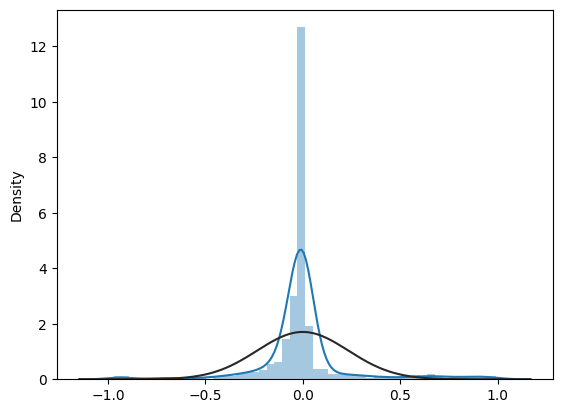

In [237]:
sns.distplot(model1.resid_generalized, fit=stats.norm)

Распределение остатков отличается от нормального распределения.

In [238]:
vifs = np.array([vif(model1.model.exog, i) for i in range(model1.model.exog.shape[1])])

In [239]:
vif_df = pd.DataFrame()
vif_df['VIF'] = vifs[1:]
vif_df['Features'] = model1.params.index[1:]
vif_df.sort_values(by=['VIF'])

,VIF,Features
3,1.003431,Male
5,1.025717,Continent_AN
1,1.123730,Area Income
9,1.133210,Continent_SA
2,1.137211,Age
0,1.218688,Daily Time Spent on Site
8,1.232381,Continent_OC
7,1.295618,Continent_NA
6,1.338834,Continent_AS
4,1.354777,Continent_AF


Нет значений VIF, превышающих 10. Проблема мультиколлинеарности отсутствует.

In [240]:
df_model1['probability'] = model1.predict()
df_model1

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Continent,Continent_AF,Continent_AN,Continent_AS,Continent_EU,Continent_NA,Continent_OC,Continent_SA,probability
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,AF,1,0,0,0,0,0,0,0.439061
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,OC,0,0,0,0,0,1,0,0.005923
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,EU,0,0,0,1,0,0,0,0.161036
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,EU,0,0,0,1,0,0,0,0.092319
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,EU,0,0,0,1,0,0,0,0.164181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1,AS,0,0,1,0,0,0,0,0.027159
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1,EU,0,0,0,1,0,0,0,0.977221
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1,AS,0,0,1,0,0,0,0,0.999682
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0,NA,0,0,0,0,1,0,0,0.925240


In [241]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_mult, y, test_size=0.2, random_state=0)

In [242]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_train)
clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
print("Train Result:\n================================================")
print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
print("_______________________________________________")
print(f"CLASSIFICATION REPORT:\n{clf_report}")
print("_______________________________________________")
print(f"Confusion Matrix: \n {confusion_matrix(y_train, pred)}\n")

Train Result:
Accuracy Score: 90.38%
_______________________________________________
CLASSIFICATION REPORT:
                    0           1  accuracy   macro avg  weighted avg
precision    0.885086    0.923274   0.90375    0.904180      0.904561
recall       0.923469    0.884804   0.90375    0.904137      0.903750
f1-score     0.903870    0.903630   0.90375    0.903750      0.903747
support    392.000000  408.000000   0.90375  800.000000    800.000000
_______________________________________________
Confusion Matrix: 
 [[362  30]
 [ 47 361]]



In [244]:
pred = lr.predict(X_test)
clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))

print("Test Result:\n================================================")
print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
print("_______________________________________________")
print(f"CLASSIFICATION REPORT:\n{clf_report}")
print("_______________________________________________")
print(f"Confusion Matrix: \n {confusion_matrix(y_test, pred)}\n")

Test Result:
Accuracy Score: 90.00%
_______________________________________________
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.879310   0.928571       0.9    0.903941      0.901970
recall       0.944444   0.847826       0.9    0.896135      0.900000
f1-score     0.910714   0.886364       0.9    0.898539      0.899513
support    108.000000  92.000000       0.9  200.000000    200.000000
_______________________________________________
Confusion Matrix: 
 [[102   6]
 [ 14  78]]



Представленные результаты демонстрируют высокую и стабильную эффективность модели. На тестовых данных достигнута точность (Accuracy) в 90%, что почти совпадает с результатом на обучающей выборке (90.38%), что указывает на хорошую обобщающую способность модели без значительного переобучения.


In [245]:
# macro avg
0.5*0.879310 + 0.5*0.928571

0.9039405

In [246]:
# weighted avg
(108/200)*0.879310 + (92/200)*0.928571

0.90197006

5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных (общие содержательные выводы - это не копирование того, что вы писали в предыдущих пунктах). Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

Вывод:

Оптимальный пользователь, который кликнет на рекламу - это женщины 35+ лет со средним достатком, принимающие быстрые решения (первые 2-3 минуты на сайте), проживающие в Европе, Азии, Северной Америке или Африке (различия между этими регионами статистически незначимы)

Для меня неочевидным стало, что время проведеня на сайте негативно влияет на шанс отклика и что Африка имеет небольшую разницу по отклику, например, с Европой, в которой развитых стран намного больше. Также удивительным фактом является, что люди с более высоким доход реже откликаются на рекламу, и повышение дохода уменшает шанс на отклик.

Не все мои гипотезы подтвердились, а гипотеза про континенты подтвердилась частично: в Южной Америки и Антаркиды действительно мало развитых стран, однако я думала, что к ним можно было и отнести страны Африки, что оказалрсь не так.

Исправиленные выводы:
- Чем больше времени человек провел на сайте, чем НИЖЕ вероятность того, что он откликнется на рекламу
- Чем больше средний доход по региону, тем НИЖЕ шансы, что человек нажмет на рекламу




Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться выполненным фрагментом кода. В этом задании будет проверяться корректность работы кода, то есть будут последовательно запущены ячейки, чтобы убедиться, что код не выдаст ошибку в какой-то момент. Перед отправкой работы на проверку рекомендуется "прогнать" код.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов регрессионного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях методов.
 - В этом задании 5 пунктов. Первый весит 15%, второй - 20%, третий - 30%, четвертый - 20%, пятый - 15%.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 2 декабря.

- При сдаче работы до 23:55 3 декабря вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 4 декабря вычитаются 2 балла из итоговой оценки.
- После **23:55 4 декабря** работа не принимается.